In [1]:
import matplotlib.pyplot as plt

def read_metrics(file_path):
    f = open(file_path, 'r')
    lines = f.readlines()
    f.close()
    metrics = {}
    for line in lines:
        if line.startswith('epoch') or line.startswith('batch'):
            start_idx = 2 if line.startswith('epoch') else 1
            line = line.split(', ')
            for i in range(start_idx, len(line)):
                item = line[i].split(': ')
                
                k = item[-2]
                v = item[-1]
                if k not in metrics:
                    metrics[k] = []
                metrics[k].append(float(v))
    return metrics

def smooth(loss, window_size=10):
    smoothed_loss = []
    half_window = window_size // 2
    for i in range(len(loss)):
        if i < half_window:
            smoothed_loss.append(sum(loss[:i+1]) / (i+1))
        elif i >= len(loss) - half_window:
            smoothed_loss.append(sum(loss[i-half_window:]) /  (half_window + len(loss) - i))
        else:
            smoothed_loss.append(sum(loss[i-half_window:i+half_window]) / window_size)
    return smoothed_loss

In [2]:
# trial_name = "data-pretrain-reviews"
trial_name = "data-pretrain-dclm"

our_metrics = read_metrics(f'../logs/{trial_name}.txt')
# moe_metrics = read_metrics('../logs/wrong-oracle-auxloss.txt')

for metric, values in our_metrics.items():
    our_metrics[metric] = smooth(values[:32000:8] + values[32000::8], window_size=10)
# for metric, values in moe_metrics.items():
#     moe_metrics[metric] = smooth(values, window_size=1000)

print(our_metrics.keys())

dict_keys(['loss', 'aux_loss'])


48294 2.8930000000000002


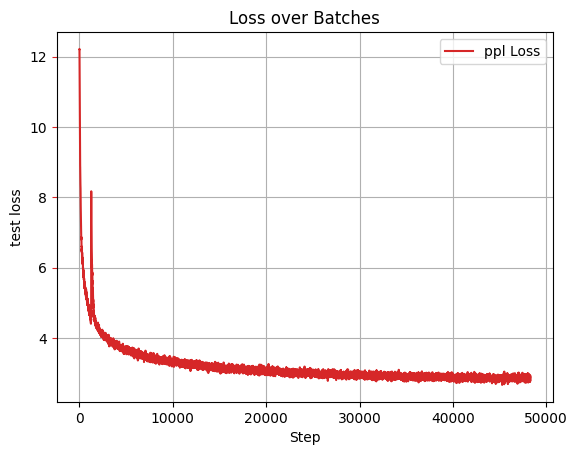

In [3]:
fig, ax1 = plt.subplots()

line1, = ax1.plot(our_metrics['loss'], label='ppl Loss', color="tab:red")
# line2, = ax1.plot(our_metrics['aux_loss'], label = 'aux loss')
print(len(our_metrics['loss']),our_metrics['loss'][-1])
ax1.set_xlabel('Step')
ax1.set_ylabel('test loss')
ax1.tick_params(axis="y", color = "tab:red")
ax1.legend()
# ax1.set_ylim(2,11)
# ax1.set_xlim(0, 1000)

# ax2 = ax1.twinx()
# line2, = ax2.plot(our_metrics['logits_loss'], label='KLD Loss', color= "tab:blue")
# ax2.set_ylabel('kl-divergence')
# ax2.tick_params(axis="y", color = "tab:blue")
# ax2.set_yscale('log')
# ax2.set_ylim(0, 2000)

# ax1.legend([line1, line2], [line1.get_label(), line2.get_label()])
# plt.plot(lr, label='Learning Rate')
plt.title('Loss over Batches')
# plt.legend()
plt.grid()
# plt.savefig(f"../figures/plots/{trial_name}-l2-kld.png")

In [4]:
plt.plot(our_metrics['teacher_ppl'], label='Teacher Perplexity')
plt.plot(our_metrics['student_ppl'], label='Student Perplexity(Oracle)')
# plt.plot(moe_metrics['student_ppl'], label='Student Perplexity(Identical)')
# plt.plot(lr, label='Learning Rate')
plt.xlabel('Step')
plt.ylabel('Value')
plt.title('Test Perplexity over Batches')
# plt.ylim(7,  20)
# plt.yscale('log')
plt.legend()
plt.grid()
plt.savefig(f"../figures/plots/{trial_name}-ppl.png")

KeyError: 'teacher_ppl'

In [ ]:
plt.plot(our_metrics['aux_loss'], label='Auxiliary Loss(Oracle)')
# plt.plot(moe_metrics['aux_loss'], label='Auxiliary Loss(Identical)')
# plt.plot(lr, label='Learning Rate')
plt.xlabel('Step')
plt.ylabel('Value')
plt.title('Auxiliary Loss over Batches')
# plt.yscale('log')
# plt.xlim(0, 10000)
# plt.ylim(0, 20)
plt.legend()
plt.grid()
plt.savefig(f"../figures/plots/{trial_name}-auxloss.png")

KeyError: 'aux_loss'